# **Heart Disease Risk Prediction based on various health factors**
### **Student name:** Vanshika Bansal
### **Student ID:** 23B2228
### **Dataset Source:** Framingham Heart Study  
---
This notebook performs an **exploratory data analysis (EDA)** on the Framingham Heart Study dataset to understand risk factors for heart disease.  
We will:
- **Analyze the dataset** (size, structure, missing values)
- **Handle missing data**
- **Perform exploratory visualizations**
- **Identify feature correlations**
---


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visualization style
sns.set_style("whitegrid")


In [32]:
file_path = "framingham.csv"
df = pd.read_csv(file_path)

# Displaying first 5 rows
df.head()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [33]:
df.shape

(4240, 16)

## **Dataset Overview**
We first check:
- The **number of rows and columns**
- The **data types** of each column
- The **first few rows** for an initial glance
---


In [34]:
# Display dataset info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [35]:
# Summary statistics
df.describe()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [36]:
df.nunique()

,0
male,2
age,39
education,4
currentSmoker,2
cigsPerDay,33
BPMeds,2
prevalentStroke,2
prevalentHyp,2
diabetes,2
totChol,248


In [37]:
# Checking for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values


,0
education,105
cigsPerDay,29
BPMeds,53
totChol,50
BMI,19
heartRate,1
glucose,388


##  Data Health Check

 **Missing Values Detected** in some columns (handled below).  
 **No Duplicate Rows** detected in the dataset.    

###  Conclusion
✅ The data is **mostly healthy**, but requires:  
1️⃣ **Handling missing values** (done in the next step).

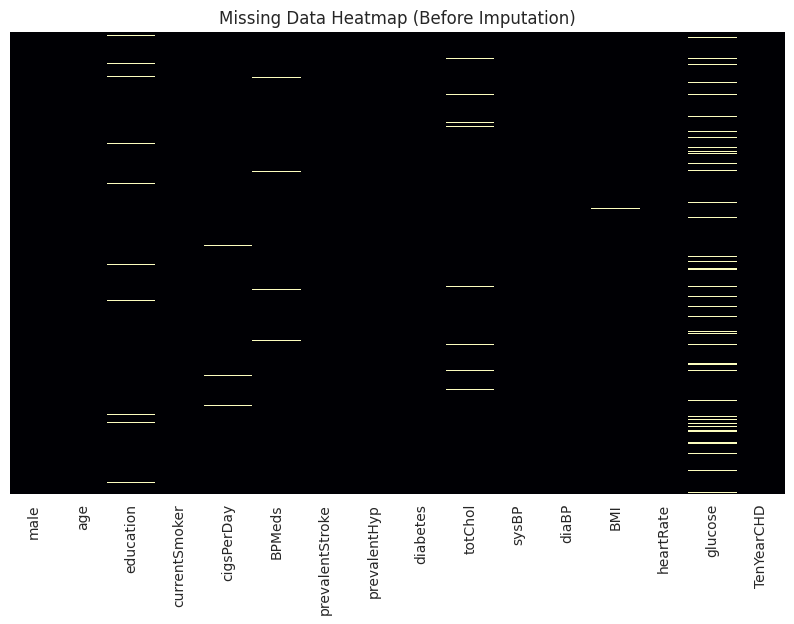

In [38]:
# Pre-Imputation Missing Data Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="magma", yticklabels=False)
plt.title("Missing Data Heatmap (Before Imputation)")
plt.show()


## **Handling Missing Values**
We will fill missing values with the **median** of each column because:
- **Median is resistant to outliers** (unlike mean).
- This helps maintain a balanced dataset without introducing bias.
---


In [39]:

df.fillna(df.median(), inplace=True)

## **Exploratory Data Analysis (EDA)**
We will now visualize:
1. **Target variable distribution**  
2. **Missing data heatmap**  
3. **Feature correlation heatmap**  
4. **Age distribution**  
5. **Cholesterol level distribution**  
---


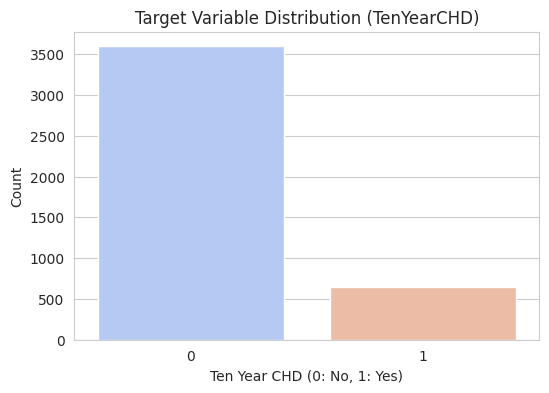

In [40]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df["TenYearCHD"], hue=df["TenYearCHD"], palette="coolwarm", legend=False)
plt.title("Target Variable Distribution (TenYearCHD)")
plt.xlabel("Ten Year CHD (0: No, 1: Yes)")
plt.ylabel("Count")
plt.show()


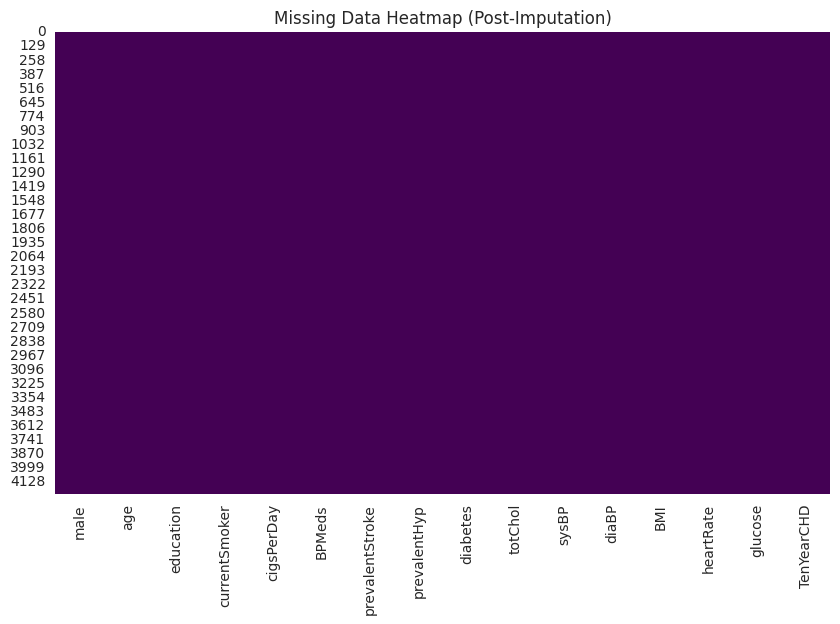

In [41]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap (Post-Imputation)")
plt.show()


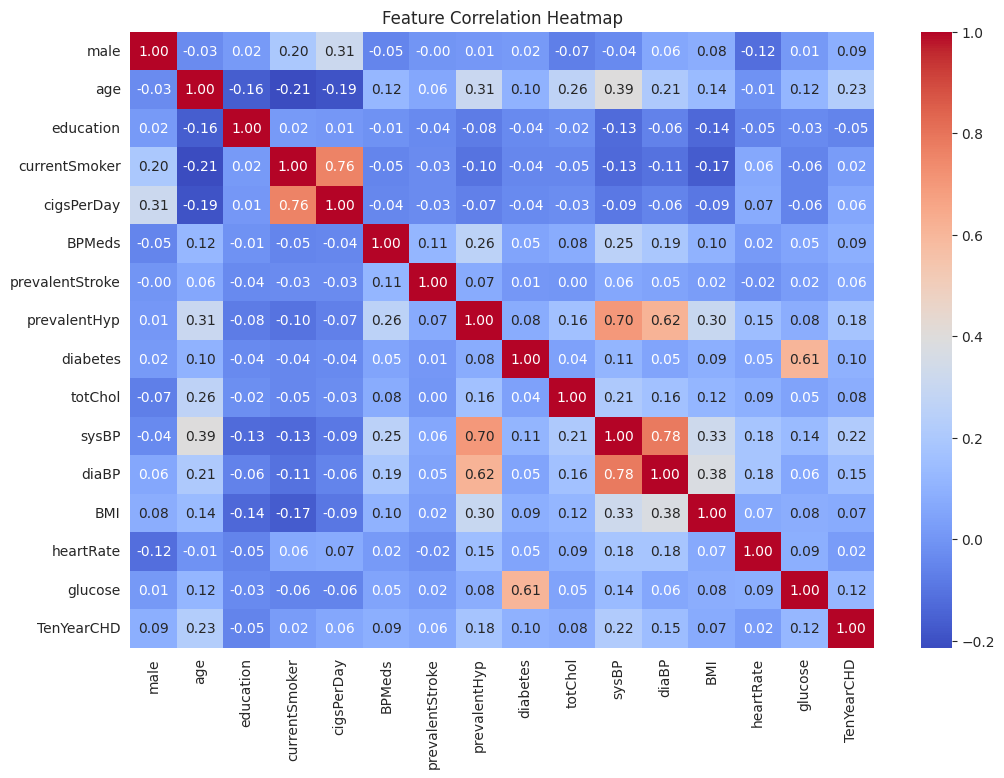

In [42]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


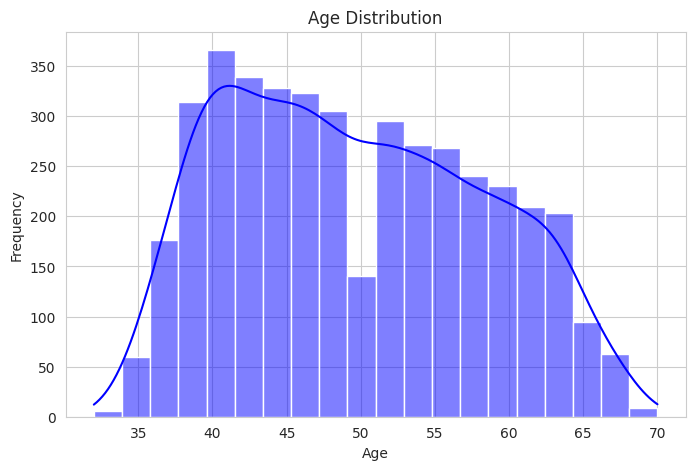

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=20, kde=True, color="blue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


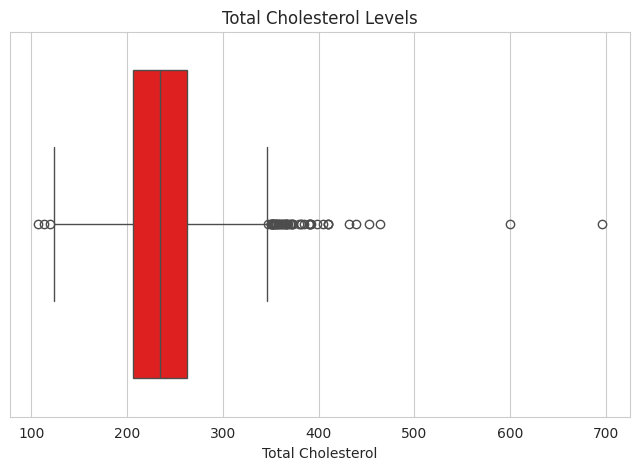

In [44]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["totChol"], color="red")
plt.title("Total Cholesterol Levels")
plt.xlabel("Total Cholesterol")
plt.show()


## **Conclusion**
- The dataset is **cleaned**, with missing values handled using median imputation.
- The **target variable (TenYearCHD)** shows an **imbalance** (fewer 1s than 0s).
- **Age and cholesterol distributions** provide insights into heart disease risks.
---

